<a href="https://colab.research.google.com/github/aldenleeSMU/FX-Regime-Engine/blob/main/Volatility_Regime_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from datetime import datetime
from IPython.display import display, HTML

In [2]:
# ============================================================
# USER SETTINGS
# ============================================================

# -------- DATA RANGE --------
start_date = "2024-06-01"   # enough warm-up history for rolling features
end_date = datetime.today().strftime("%Y-%m-%d")

# -------- REGIME PARAMETERS --------
rolling_vol_window = 20
zscore_window = 60
trading_days = 252

# -------- SCORE WEIGHTS --------
w_vol = 0.45
w_vol_change = 0.30
w_gold = 0.25

# -------- ACCOUNT SETTINGS --------
start_equity = 100000.0
base_risk_pct = 0.50   # base risk per trade in %

# -------- TRADE FILE PATH --------
trade_file = "/content/Raw Trades Data 2025/Alpha Capital YTD Performance 2025(Raw Trades).csv"

In [3]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def check_file_exists(path: str):
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Trade file not found: {path}\n"
            f"Run os.listdir('/content') to check the exact filename."
        )

def download_close(ticker: str, start_date: str, end_date: str) -> pd.DataFrame:
    df = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        auto_adjust=True,
        progress=False
    )

    if df.empty:
        raise ValueError(f"No data returned for ticker: {ticker}")

    if isinstance(df.columns, pd.MultiIndex):
        if ("Close", ticker) in df.columns:
            close = df[("Close", ticker)].copy()
        else:
            close = df.xs("Close", axis=1, level=0).iloc[:, 0].copy()
    else:
        if "Close" not in df.columns:
            raise ValueError(f"'Close' column not found for ticker: {ticker}")
        close = df["Close"].copy()

    out = pd.DataFrame(index=pd.to_datetime(close.index))
    out["close"] = pd.to_numeric(close, errors="coerce")
    out.index.name = "date"
    return out.dropna()

def rolling_zscore(series: pd.Series, window: int) -> pd.Series:
    mean_ = series.rolling(window).mean()
    std_ = series.rolling(window).std()
    z = (series - mean_) / std_
    return z.replace([np.inf, -np.inf], np.nan)

def normalize_0_100(series: pd.Series) -> pd.Series:
    s_min = series.min()
    s_max = series.max()

    if pd.isna(s_min) or pd.isna(s_max) or s_max == s_min:
        raise ValueError("Normalization failed: series has insufficient variation.")

    return 100 * (series - s_min) / (s_max - s_min)

def label_regime(score: float) -> str:
    if pd.isna(score):
        return np.nan
    if score >= 75:
        return "Strong"
    elif score >= 50:
        return "Good"
    elif score >= 25:
        return "Mixed"
    else:
        return "Poor"

def clean_numeric_column(series: pd.Series) -> pd.Series:
    return (
        series.astype(str)
        .str.replace("%", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip()
        .replace("", np.nan)
        .pipe(pd.to_numeric, errors="coerce")
    )

def build_equity_from_pnl(pnl_series: pd.Series, start_equity: float = 100000.0) -> pd.Series:
    pnl_series = pd.Series(pnl_series).fillna(0.0).astype(float)
    equity = start_equity + pnl_series.cumsum()
    return equity

def drawdown_series(equity_series: pd.Series) -> pd.Series:
    equity_series = pd.Series(equity_series).astype(float)
    running_peak = equity_series.cummax()
    return (equity_series / running_peak) - 1.0

def max_drawdown(equity_series: pd.Series) -> float:
    return drawdown_series(equity_series).min()

def performance_metrics(trade_returns_pct: pd.Series, equity_series: pd.Series) -> dict:
    r = pd.Series(trade_returns_pct).dropna().astype(float) / 100.0
    eq = pd.Series(equity_series).dropna().astype(float)

    if len(eq) < 2:
        total_return = np.nan
    else:
        total_return = (eq.iloc[-1] / eq.iloc[0]) - 1

    mean_ret = r.mean() if len(r) > 0 else np.nan
    std_ret = r.std(ddof=1) if len(r) > 1 else np.nan
    sharpe = (mean_ret / std_ret) * np.sqrt(252) if pd.notna(std_ret) and std_ret > 0 else np.nan

    downside = r[r < 0]
    downside_std = downside.std(ddof=1) if len(downside) > 1 else np.nan
    sortino = (mean_ret / downside_std) * np.sqrt(252) if pd.notna(downside_std) and downside_std > 0 else np.nan

    mdd = max_drawdown(eq) if len(eq) > 0 else np.nan

    wins = r[r > 0]
    losses = r[r < 0]

    win_rate = len(wins) / len(r) if len(r) > 0 else np.nan
    avg_win = wins.mean() if len(wins) > 0 else np.nan
    avg_loss = losses.mean() if len(losses) > 0 else np.nan
    expectancy = r.mean() if len(r) > 0 else np.nan

    gross_profit = wins.sum() if len(wins) > 0 else 0.0
    gross_loss = abs(losses.sum()) if len(losses) > 0 else 0.0
    profit_factor = gross_profit / gross_loss if gross_loss > 0 else np.nan

    return {
        "Total Return": total_return,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Max Drawdown": mdd,
        "Win Rate": win_rate,
        "Avg Win": avg_win,
        "Avg Loss": avg_loss,
        "Expectancy": expectancy,
        "Profit Factor": profit_factor,
        "Trades": len(r)
    }

def format_metrics_table(metrics_dict: dict) -> pd.DataFrame:
    df = pd.DataFrame(metrics_dict)

    pct_rows = ["Total Return", "Max Drawdown", "Win Rate", "Avg Win", "Avg Loss", "Expectancy"]
    for row in pct_rows:
        if row in df.index:
            df.loc[row] = df.loc[row].astype(float).map(
                lambda x: f"{x:.2%}" if pd.notna(x) else ""
            )

    for row in ["Sharpe", "Sortino", "Profit Factor"]:
        if row in df.index:
            df.loc[row] = df.loc[row].astype(float).map(
                lambda x: f"{x:.2f}" if pd.notna(x) else ""
            )

    if "Trades" in df.index:
        df.loc["Trades"] = df.loc["Trades"].astype(float).map(
            lambda x: f"{int(x)}" if pd.notna(x) else ""
        )

    return df

In [4]:
# ============================================================
# 1. DOWNLOAD MARKET DATA
# ============================================================

eurusd = download_close("EURUSD=X", start_date, end_date)
gold = download_close("GC=F", start_date, end_date)

regime_df = eurusd.rename(columns={"close": "eurusd_close"}).join(
    gold.rename(columns={"close": "gold_close"}),
    how="inner"
)

regime_df["eurusd_ret"] = regime_df["eurusd_close"].pct_change()
regime_df["gold_ret"] = regime_df["gold_close"].pct_change()

regime_df["eurusd_rolling_vol"] = (
    regime_df["eurusd_ret"].rolling(rolling_vol_window).std() * np.sqrt(trading_days)
)

regime_df["eurusd_vol_change"] = regime_df["eurusd_rolling_vol"].diff()
regime_df["gold_mom_20"] = regime_df["gold_close"].pct_change(20)

regime_df["eurusd_vol_z"] = rolling_zscore(regime_df["eurusd_rolling_vol"], zscore_window)
regime_df["eurusd_vol_change_z"] = rolling_zscore(regime_df["eurusd_vol_change"], zscore_window)
regime_df["gold_mom_z"] = rolling_zscore(regime_df["gold_mom_20"], zscore_window)

# Components:
# Higher EURUSD vol can be favourable
# Falling vol-change can be favourable, so we invert vol_change_z
# Strong gold momentum can be unfavourable, so we invert gold_mom_z
regime_df["comp_vol"] = regime_df["eurusd_vol_z"]
regime_df["comp_vol_change"] = -regime_df["eurusd_vol_change_z"]
regime_df["comp_gold"] = -regime_df["gold_mom_z"]

regime_df["score_raw"] = (
    w_vol * regime_df["comp_vol"] +
    w_vol_change * regime_df["comp_vol_change"] +
    w_gold * regime_df["comp_gold"]
)

regime_df = regime_df.dropna(subset=["score_raw"]).copy()
regime_df["regime_score"] = normalize_0_100(regime_df["score_raw"]).clip(0, 100)
regime_df["regime_label"] = regime_df["regime_score"].apply(label_regime)
regime_df = regime_df.reset_index()

print("EURUSD rows:", len(eurusd))
print("Gold rows:", len(gold))
print("Regime rows:", len(regime_df))


EURUSD rows: 466
Gold rows: 454
Regime rows: 373


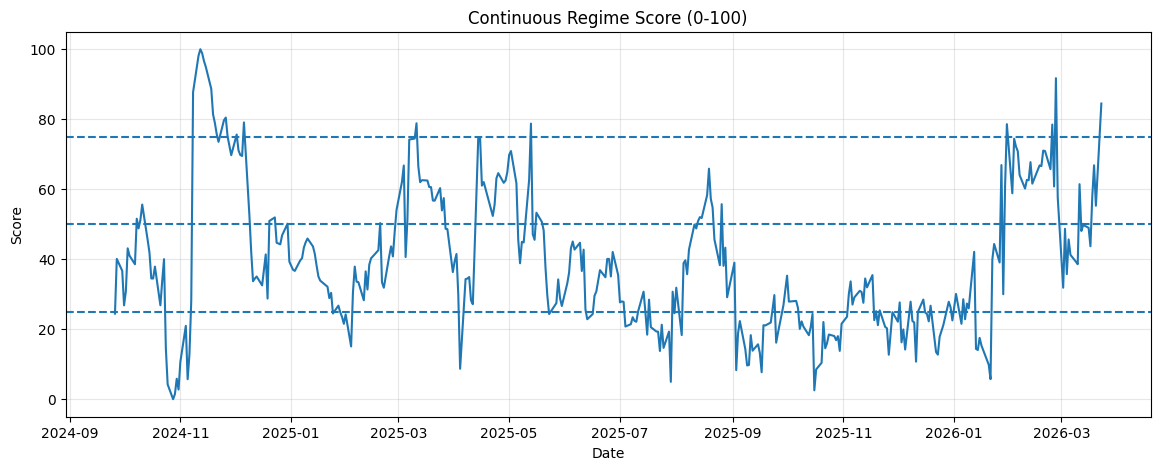

In [5]:
# ============================================================
# 2. PLOT REGIME SCORE
# ============================================================

plt.figure(figsize=(14, 5))
plt.plot(regime_df["date"], regime_df["regime_score"], linewidth=1.5)
plt.axhline(75, linestyle="--")
plt.axhline(50, linestyle="--")
plt.axhline(25, linestyle="--")
plt.title("Continuous Regime Score (0-100)")
plt.xlabel("Date")
plt.ylabel("Score")
plt.grid(True, alpha=0.3)
plt.show()

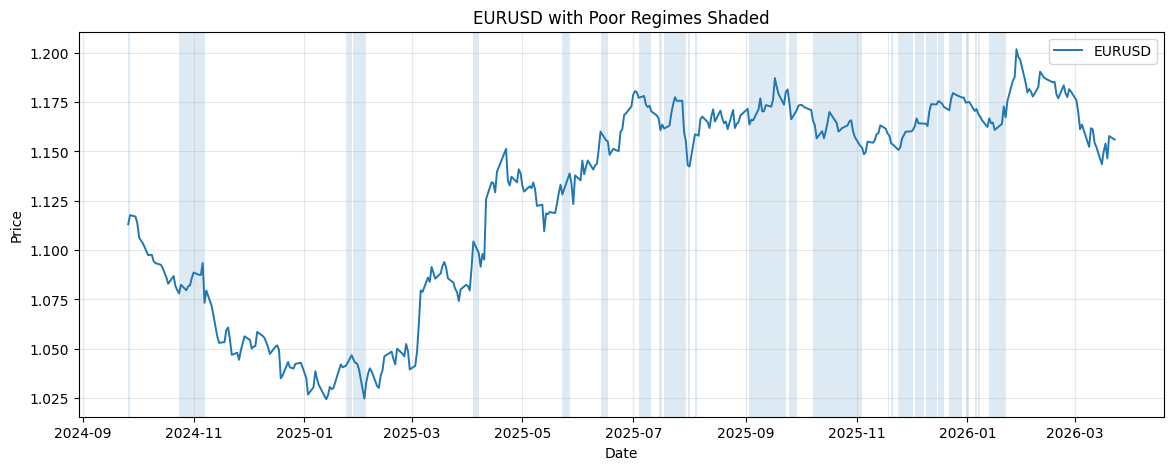

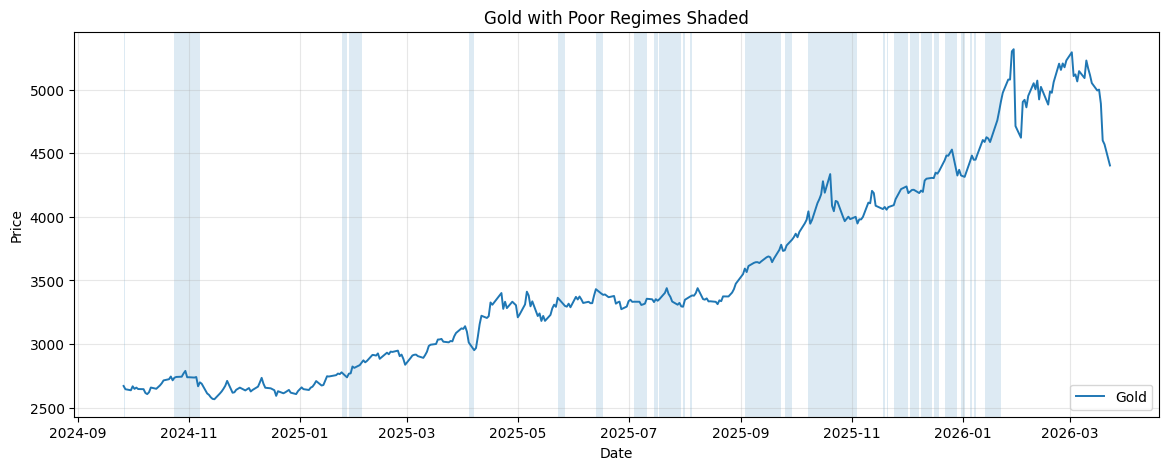

In [6]:
# ============================================================
# 3. SHADED PRICE CHARTS
# ============================================================

poor_mask = regime_df["regime_label"] == "Poor"

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(regime_df["date"], regime_df["eurusd_close"], label="EURUSD", linewidth=1.4)
for i in range(len(regime_df) - 1):
    if poor_mask.iloc[i]:
        ax.axvspan(regime_df["date"].iloc[i], regime_df["date"].iloc[i + 1], alpha=0.15)
ax.set_title("EURUSD with Poor Regimes Shaded")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(regime_df["date"], regime_df["gold_close"], label="Gold", linewidth=1.4)
for i in range(len(regime_df) - 1):
    if poor_mask.iloc[i]:
        ax.axvspan(regime_df["date"].iloc[i], regime_df["date"].iloc[i + 1], alpha=0.15)
ax.set_title("Gold with Poor Regimes Shaded")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

In [8]:
# ============================================================
# 4. LOAD TRADE CSV FROM COLAB FILES
# ============================================================

check_file_exists(trade_file)
trades = pd.read_csv(trade_file)

print("Raw columns:")
print(trades.columns.tolist())

Raw columns:
['Trade no.', 'Date', 'Pair', 'Direction', 'R-Multiple', ' P&L ($)', 'Return (%)', 'Day ', '$100,000', 'Open Time', 'Close Time', 'Duration', 'week_start', 'weekday_Num', 'Session', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27']


In [9]:
# ============================================================
# 5. CLEAN TRADE LOG
# ============================================================

trades.columns = trades.columns.str.strip()
print("\nCleaned columns:")
print(trades.columns.tolist())

required_cols = ["Date", "Pair"]
for col in required_cols:
    if col not in trades.columns:
        raise ValueError(f"Required column missing from CSV: {col}")

trades["Date"] = pd.to_datetime(trades["Date"], errors="coerce").dt.normalize()
trades["Pair"] = trades["Pair"].astype(str).str.strip().str.upper()

# Standard numeric fields if present
numeric_candidates = ["Return (%)", "P&L ($)", "$100,000", "R-Multiple"]
for col in numeric_candidates:
    if col in trades.columns:
        trades[col] = clean_numeric_column(trades[col])

# Optional cleanup of pair names if needed
pair_map = {
    "XAU/USD": "XAUUSD",
    "EUR/USD": "EURUSD"
}
trades["Pair"] = trades["Pair"].replace(pair_map)

trades = trades.dropna(subset=["Date", "Pair"]).sort_values("Date").reset_index(drop=True)

if "Return (%)" not in trades.columns:
    raise ValueError("Column 'Return (%)' not found in trade CSV.")

if "P&L ($)" not in trades.columns:
    raise ValueError("Column 'P&L ($)' not found in trade CSV.")

print("\nTrade sample:")
display(trades.head())


Cleaned columns:
['Trade no.', 'Date', 'Pair', 'Direction', 'R-Multiple', 'P&L ($)', 'Return (%)', 'Day', '$100,000', 'Open Time', 'Close Time', 'Duration', 'week_start', 'weekday_Num', 'Session', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27']

Trade sample:


,Trade no.,Date,Pair,Direction,R-Multiple,P&L ($),Return (%),Day,"$100,000",Open Time,...,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27
0,1.0,2025-03-13,EURUSD,Long,-0.96,-478.50,-0.48,Thursday,99521.50,6:47:00 PM,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,2025-03-14,XAUUSD,Long,3.50,1750.80,1.75,Friday,101272.30,4:02:00 PM,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3.0,2025-03-14,EURUSD,Long,1.49,744.00,0.74,Friday,102016.30,4:19:00 PM,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4.0,2025-03-17,XAUUSD,Short,-1.06,-528.14,-0.53,Monday,101488.16,11:21:00 PM,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5.0,2025-03-20,EURUSD,Long,-1.23,-616.20,-0.62,Thursday,100871.96,5:15:00 PM,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# ============================================================
# 6. MAP DAILY REGIME TO TRADES
# ============================================================

daily_regime = pd.DataFrame({
    "Date": pd.date_range(regime_df["date"].min(), regime_df["date"].max(), freq="D")
})

daily_regime = daily_regime.merge(
    regime_df[["date", "regime_score", "regime_label"]],
    left_on="Date",
    right_on="date",
    how="left"
).sort_values("Date")

daily_regime["regime_score"] = daily_regime["regime_score"].ffill()
daily_regime["regime_label"] = daily_regime["regime_label"].ffill()
daily_regime = daily_regime[["Date", "regime_score", "regime_label"]]

trades = trades.merge(daily_regime, on="Date", how="left")

print("Missing regime scores:", trades["regime_score"].isna().sum())

Missing regime scores: 0


In [11]:
# ============================================================
# 7. REGIME BUCKETS
# ============================================================

trades["regime_bucket"] = pd.cut(
    trades["regime_score"],
    bins=[0, 25, 50, 75, 100],
    labels=["Poor", "Mixed", "Good", "Strong"],
    include_lowest=True
)

display(trades[["Date", "Pair", "regime_score", "regime_bucket"]].head(10))

,Date,Pair,regime_score,regime_bucket
0,2025-03-13,EURUSD,62.014432,Good
1,2025-03-14,XAUUSD,62.581771,Good
2,2025-03-14,EURUSD,62.581771,Good
3,2025-03-17,XAUUSD,62.486225,Good
4,2025-03-20,EURUSD,56.772341,Good
5,2025-03-20,XAUUSD,56.772341,Good
6,2025-03-20,XAUUSD,56.772341,Good
7,2025-03-20,XAUUSD,56.772341,Good
8,2025-03-21,XAUUSD,56.726467,Good
9,2025-03-25,XAUUSD,53.941753,Good



Pair x Regime stats:


trades_count  avg_return_pct  median_return_pct  \
Pair   regime_bucket                                                    
EURUSD Poor                     46        0.021876             -0.235   
       Mixed                    48        0.012976             -0.285   
       Good                     23        0.170000             -0.080   
       Strong                    0             NaN                NaN   
XAUUSD Poor                     27        0.075185             -0.250   
       Mixed                    27        0.090741             -0.350   
       Good                     26        0.009615             -0.310   
       Strong                    1       -0.010000             -0.010   

                       win_rate  avg_r_multiple  
Pair   regime_bucket                             
EURUSD Poor           28.260870        0.119348  
       Mixed          25.000000        0.019058  
       Good           39.130435        0.338261  
       Strong               NaN             NaN  
XAUUSD Poor           37.037037        0.305556  
       Mixed          25.925926        0.180370  
       Good           34.615385        0.019231  
       Strong          0.000000       -0.010000

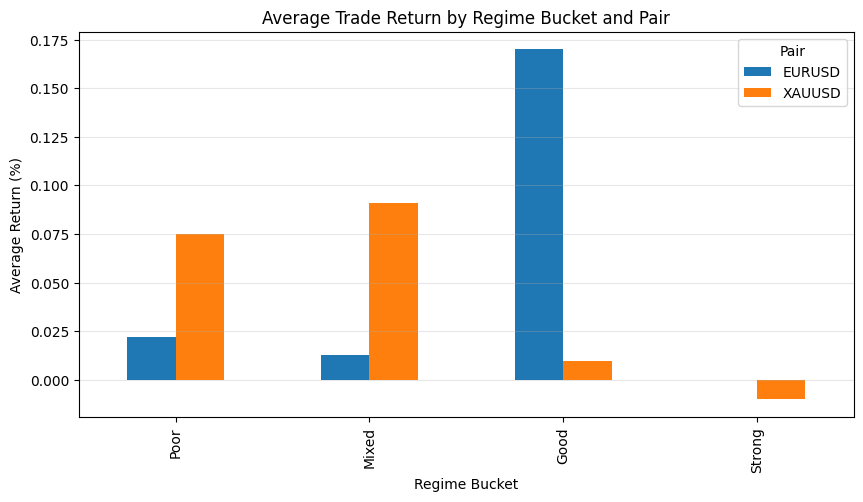

In [12]:
# ============================================================
# 8. REGIME DIAGNOSTICS BY PAIR
# ============================================================

agg_dict = {
    "trades_count": ("Return (%)", "count"),
    "avg_return_pct": ("Return (%)", "mean"),
    "median_return_pct": ("Return (%)", "median"),
    "win_rate": ("Return (%)", lambda x: (x > 0).mean() * 100)
}

if "R-Multiple" in trades.columns:
    agg_dict["avg_r_multiple"] = ("R-Multiple", "mean")

pair_bucket_stats = trades.groupby(
    ["Pair", "regime_bucket"], observed=False
).agg(**agg_dict)

print("\nPair x Regime stats:")
display(pair_bucket_stats)

pair_bucket_plot = trades.groupby(
    ["Pair", "regime_bucket"], observed=False
)["Return (%)"].mean().unstack(0)

pair_bucket_plot.plot(kind="bar", figsize=(10, 5))
plt.title("Average Trade Return by Regime Bucket and Pair")
plt.xlabel("Regime Bucket")
plt.ylabel("Average Return (%)")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

In [13]:
# ============================================================
# 9. PAIR-SPECIFIC POSITION SIZING RULES
# ============================================================

def pair_specific_size(row):
    pair = row['Pair']
    bucket = row['regime_bucket']

    if pd.isna(bucket):
        return 1.0

    # EURUSD rules
    if pair == 'EURUSD':
        if bucket == 'Good':
            return 1.00
        elif bucket == 'Mixed':
            return 0.50
        elif bucket == 'Strong':
            return 1.00
        else:   # Poor
            return 0.75

    # XAUUSD rules
    elif pair == 'XAUUSD':
        if bucket == 'Good':
            return 0.50
        elif bucket == 'Mixed':
            return 1.00
        elif bucket == 'Strong':
            return 0.25
        else:   # Poor
            return 1.00

    # Fallback
    else:
        return 1.00

trades['size_mult'] = trades.apply(pair_specific_size, axis=1)

trades[['Date', 'Pair', 'regime_bucket', 'size_mult']].head(20)

,Date,Pair,regime_bucket,size_mult
0,2025-03-13,EURUSD,Good,1.0
1,2025-03-14,XAUUSD,Good,0.5
2,2025-03-14,EURUSD,Good,1.0
3,2025-03-17,XAUUSD,Good,0.5
4,2025-03-20,EURUSD,Good,1.0
5,2025-03-20,XAUUSD,Good,0.5
6,2025-03-20,XAUUSD,Good,0.5
7,2025-03-20,XAUUSD,Good,0.5
8,2025-03-21,XAUUSD,Good,0.5
9,2025-03-25,XAUUSD,Good,0.5


In [14]:
# ============================================================
# 10. ACTUAL VS REGIME-ADJUSTED RETURNS
# ============================================================

trades["actual_pnl"] = trades["P&L ($)"].astype(float)
trades["adjusted_pnl"] = trades["actual_pnl"] * trades["size_mult"]

trades["actual_return_pct"] = trades["Return (%)"].astype(float)
trades["adjusted_return_pct"] = trades["actual_return_pct"] * trades["size_mult"]

trades["equity_actual"] = build_equity_from_pnl(trades["actual_pnl"], start_equity)
trades["equity_adjusted"] = build_equity_from_pnl(trades["adjusted_pnl"], start_equity)

In [15]:
# ============================================================
# 11. PERFORMANCE COMPARISON
# ============================================================

actual_metrics = performance_metrics(
    trades["actual_return_pct"],
    trades["equity_actual"]
)

adjusted_metrics = performance_metrics(
    trades["adjusted_return_pct"],
    trades["equity_adjusted"]
)

comparison = format_metrics_table({
    "Actual": actual_metrics,
    "Regime Adjusted": adjusted_metrics
})

print("\nPerformance Comparison:")
display(comparison)


Performance Comparison:


,Actual,Regime Adjusted
Total Return,12.66%,11.18%
Sharpe,0.94,1.14
Sortino,3.36,4.00
Max Drawdown,-10.75%,-8.32%
Win Rate,30.30%,30.30%
Avg Win,1.10%,0.84%
Avg Loss,-0.41%,-0.30%
Expectancy,0.05%,0.05%
Profit Factor,1.18,1.23
Trades,198,198


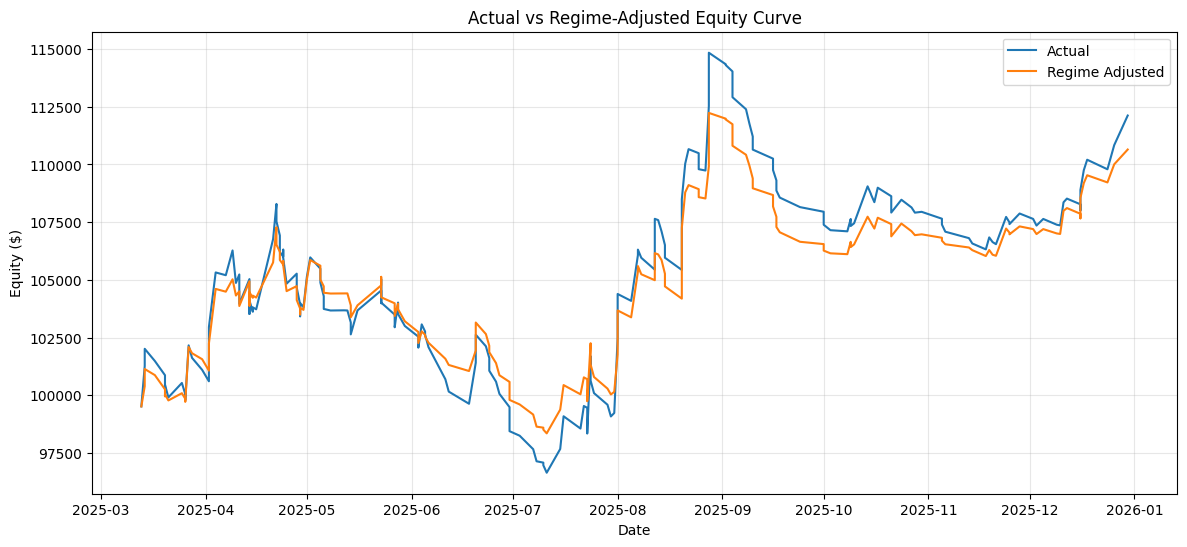

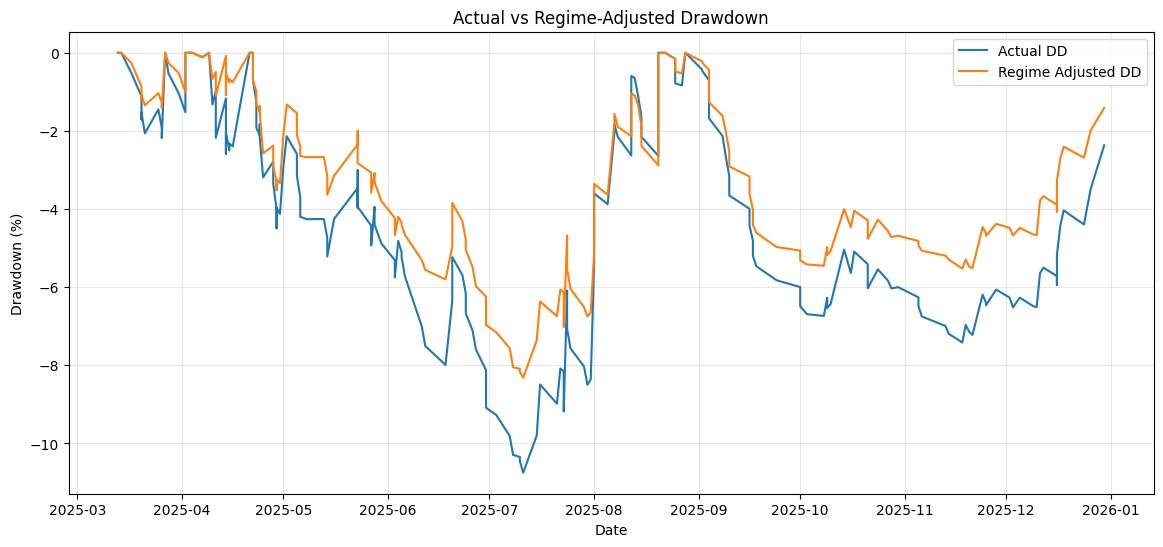

In [16]:
# ============================================================
# 12. EQUITY CURVES
# ============================================================

plt.figure(figsize=(14, 6))
plt.plot(trades["Date"], trades["equity_actual"], label="Actual", linewidth=1.5)
plt.plot(trades["Date"], trades["equity_adjusted"], label="Regime Adjusted", linewidth=1.5)
plt.title("Actual vs Regime-Adjusted Equity Curve")
plt.xlabel("Date")
plt.ylabel("Equity ($)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# ============================================================
# 13. DRAWDOWN CURVES
# ============================================================

trades["dd_actual"] = drawdown_series(trades["equity_actual"]) * 100
trades["dd_adjusted"] = drawdown_series(trades["equity_adjusted"]) * 100

plt.figure(figsize=(14, 6))
plt.plot(trades["Date"], trades["dd_actual"], label="Actual DD", linewidth=1.5)
plt.plot(trades["Date"], trades["dd_adjusted"], label="Regime Adjusted DD", linewidth=1.5)
plt.title("Actual vs Regime-Adjusted Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

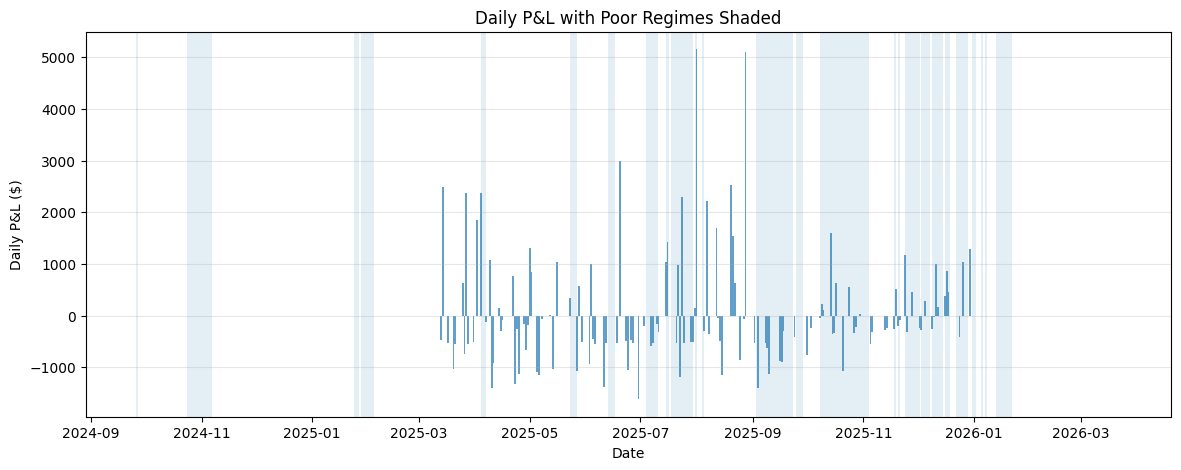

In [17]:
# ============================================================
# 14. DAILY P&L VS LOW-QUALITY REGIME
# ============================================================

daily_pnl = (
    trades.groupby("Date", as_index=True)["actual_pnl"]
    .sum()
    .sort_index()
    .to_frame(name="daily_pnl")
)

regime_daily = regime_df[["date", "regime_label"]].copy()
regime_daily["date"] = pd.to_datetime(regime_daily["date"]).dt.normalize()
regime_daily = regime_daily.set_index("date")

plot_df = regime_daily.join(daily_pnl, how="left")
plot_df["daily_pnl"] = plot_df["daily_pnl"].fillna(0)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(plot_df.index, plot_df["daily_pnl"], width=1.0, alpha=0.7)

poor_mask = plot_df["regime_label"] == "Poor"
for i in range(len(plot_df) - 1):
    if poor_mask.iloc[i]:
        ax.axvspan(plot_df.index[i], plot_df.index[i + 1], alpha=0.12)

ax.set_title("Daily P&L with Poor Regimes Shaded")
ax.set_xlabel("Date")
ax.set_ylabel("Daily P&L ($)")
ax.grid(True, axis="y", alpha=0.3)
plt.show()

In [18]:
# @title
from IPython.display import display, HTML

base_risk = 0.5

def risk_from_bucket(pair, bucket):
    if pair == "EURUSD":
        table = {
            "Good": 1.00,
            "Mixed": 0.50,
            "Strong": 0.90,
            "Poor": 0.20
        }
    elif pair == "XAUUSD":
        table = {
            "Good": 1.00,
            "Mixed": 0.85,
            "Strong": 0.25,
            "Poor": 0.15
        }
    else:
        return np.nan

    return base_risk * table[bucket]

latest = regime_df.iloc[-1]

score = float(latest['regime_score'])
bucket = latest['regime_label']

eurusd_risk = risk_from_bucket("EURUSD", bucket)
xauusd_risk = risk_from_bucket("XAUUSD", bucket)

# Color map
bucket_color = {
    "Good": "#16a34a",    # green
    "Mixed": "#ca8a04",   # amber
    "Strong": "#2563eb",  # blue
    "Poor": "#dc2626"     # red
}.get(bucket, "#6b7280")

# Score bar width
score_width = max(0, min(score, 100))

html = f"""
<div style="
    font-family: Arial, sans-serif;
    max-width: 950px;
    margin: 20px auto;
    border: 1px solid #e5e7eb;
    border-radius: 14px;
    padding: 24px;
    background: #ffffff;
    box-shadow: 0 4px 12px rgba(0,0,0,0.06);
">
    <div style="display:flex; justify-content:space-between; align-items:center; margin-bottom:18px;">
        <div>
            <h2 style="margin:0; font-size:26px; color:#111827;">Volatility Regime Dashboard</h2>
            <p style="margin:6px 0 0 0; color:#6b7280; font-size:14px;">
                Daily risk overlay for EURUSD and XAUUSD
            </p>
        </div>
        <div style="
            padding:8px 14px;
            border-radius:999px;
            background:{bucket_color};
            color:white;
            font-weight:700;
            font-size:14px;
        ">
            {bucket.upper()}
        </div>
    </div>

    <div style="margin-bottom:20px;">
        <div style="display:flex; justify-content:space-between; margin-bottom:6px;">
            <span style="font-weight:600; color:#111827;">Regime Score</span>
            <span style="font-weight:700; color:#111827;">{score:.1f} / 100</span>
        </div>
        <div style="width:100%; background:#e5e7eb; border-radius:999px; height:14px; overflow:hidden;">
            <div style="
                width:{score_width}%;
                height:14px;
                background:{bucket_color};
                border-radius:999px;
            "></div>
        </div>
    </div>

    <div style="display:grid; grid-template-columns: repeat(3, 1fr); gap:14px; margin-bottom:20px;">
        <div style="padding:16px; border:1px solid #e5e7eb; border-radius:12px; background:#f9fafb;">
            <div style="font-size:12px; color:#6b7280; margin-bottom:6px;">EURUSD Vol Z-Score</div>
            <div style="font-size:24px; font-weight:700; color:#111827;">{latest['eurusd_vol_z']:.2f}</div>
        </div>
        <div style="padding:16px; border:1px solid #e5e7eb; border-radius:12px; background:#f9fafb;">
            <div style="font-size:12px; color:#6b7280; margin-bottom:6px;">EURUSD Vol Change Z-Score</div>
            <div style="font-size:24px; font-weight:700; color:#111827;">{latest['eurusd_vol_change_z']:.2f}</div>
        </div>
        <div style="padding:16px; border:1px solid #e5e7eb; border-radius:12px; background:#f9fafb;">
            <div style="font-size:12px; color:#6b7280; margin-bottom:6px;">Gold Momentum Z-Score</div>
            <div style="font-size:24px; font-weight:700; color:#111827;">{latest['gold_mom_z']:.2f}</div>
        </div>
    </div>

    <div style="display:grid; grid-template-columns: repeat(2, 1fr); gap:14px;">
        <div style="padding:18px; border:1px solid #dbeafe; border-radius:12px; background:#eff6ff;">
            <div style="font-size:12px; color:#6b7280; margin-bottom:8px;">Recommended EURUSD Risk</div>
            <div style="font-size:30px; font-weight:800; color:#1d4ed8;">{eurusd_risk:.3f}%</div>
        </div>
        <div style="padding:18px; border:1px solid #dcfce7; border-radius:12px; background:#f0fdf4;">
            <div style="font-size:12px; color:#6b7280; margin-bottom:8px;">Recommended XAUUSD Risk</div>
            <div style="font-size:30px; font-weight:800; color:#15803d;">{xauusd_risk:.3f}%</div>
        </div>
    </div>
</div>
"""

display(HTML(html))